# **A3 Predicing Car Prices** *ML AUG-2026*

## Submitted By: *Anish Lal Manandhar (st125973)*

**GIT REPO:**   https://github.com/anishDevMage/ML-August-2026-A3-st125973

**APP HOSTED ON:**  http://192.41.170.105:8050/

### **Data Load**

In [213]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

*Data Import*

In [214]:
df = pd.read_csv("Cars.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [215]:
df.shape

(8128, 13)

In [216]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [217]:
df['selling_price'].describe(include="number")

count    8.128000e+03
mean     6.382718e+05
std      8.062534e+05
min      2.999900e+04
25%      2.549990e+05
50%      4.500000e+05
75%      6.750000e+05
max      1.000000e+07
Name: selling_price, dtype: float64

### **Data Cleaning**
##### Few Initial Sections of Data Cleaning are performed similar to the previous assignments also since the same dataset is being used

##### *Duplicate check and drop*

In [218]:
# Check and delete for duplicates
print(df.duplicated().sum())
df = df.drop_duplicates()
df.shape

1202


(6926, 13)

In [219]:
# REMOVING ROW VALUES
df = df[~df['fuel'].isin(['CNG', 'LPG'])]
df = df[df['owner'] != 'Test Drive Car']

In [220]:
df[['mileage', 'engine', 'max_power']].dtypes

mileage      object
engine       object
max_power    object
dtype: object

Type Casting

In [221]:
df['mileage'] = df['mileage'].str.split().str[0].astype(float)
df['engine'] = df['engine'].str.split().str[0].astype(float)
df['max_power'] = df['max_power'].str.split().str[0].astype(float)

Drop Torque Column

In [222]:
# DROPPING FEATURES
df.drop('torque', axis=1, inplace=True)

*Fill Data*

In [223]:
df['brand'] = df['name'].str.split().str[0]
df['brand'] = df['brand'].fillna('Unknown')
df.drop(columns=['name'], inplace=True)

In [224]:
print("\nUnique brands in the dataset:")
print(df['brand'].unique())


Unique brands in the dataset:
['Maruti' 'Skoda' 'Honda' 'Hyundai' 'Toyota' 'Ford' 'Renault' 'Mahindra'
 'Tata' 'Chevrolet' 'Fiat' 'Datsun' 'Jeep' 'Mercedes-Benz' 'Mitsubishi'
 'Audi' 'Volkswagen' 'BMW' 'Nissan' 'Lexus' 'Jaguar' 'Land' 'MG' 'Volvo'
 'Daewoo' 'Kia' 'Force' 'Ambassador' 'Ashok' 'Isuzu' 'Opel' 'Peugeot']


##### *Null check and drop*

In [225]:
df.isnull().sum()

year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          201
engine           201
max_power        198
seats            201
brand              0
dtype: int64

In [226]:
# SMALL PERCENTAGE DELETED
df = df.dropna(subset=['mileage', 'engine', 'max_power', 'seats'])
df.isnull().sum()

year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
brand            0
dtype: int64

In [227]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6626 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           6626 non-null   int64  
 1   selling_price  6626 non-null   int64  
 2   km_driven      6626 non-null   int64  
 3   fuel           6626 non-null   object 
 4   seller_type    6626 non-null   object 
 5   transmission   6626 non-null   object 
 6   owner          6626 non-null   object 
 7   mileage        6626 non-null   float64
 8   engine         6626 non-null   float64
 9   max_power      6626 non-null   float64
 10  seats          6626 non-null   float64
 11  brand          6626 non-null   object 
dtypes: float64(4), int64(3), object(5)
memory usage: 673.0+ KB


### **Encoding**

In [228]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6626 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           6626 non-null   int64  
 1   selling_price  6626 non-null   int64  
 2   km_driven      6626 non-null   int64  
 3   fuel           6626 non-null   object 
 4   seller_type    6626 non-null   object 
 5   transmission   6626 non-null   object 
 6   owner          6626 non-null   object 
 7   mileage        6626 non-null   float64
 8   engine         6626 non-null   float64
 9   max_power      6626 non-null   float64
 10  seats          6626 non-null   float64
 11  brand          6626 non-null   object 
dtypes: float64(4), int64(3), object(5)
memory usage: 673.0+ KB


#### **Encoding Column: Owner**

In [229]:
df["owner"].unique() 

array(['First Owner', 'Second Owner', 'Third Owner',
       'Fourth & Above Owner'], dtype=object)

In [230]:
owner_mapping = {'First Owner': 1, 'Second Owner': 2, 'Third Owner': 3,
       'Fourth & Above Owner': 4}

df['owner'] = df['owner'].map(owner_mapping)
df["owner"].unique() 

array([1, 2, 3, 4])

#### **Encoding Column: Transmission**

In [231]:
df['transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [232]:
transmission_mapping = { 'Manual': 1, 'Automatic': 0 }
df["transmission"] = df['transmission'].map(transmission_mapping)
df["transmission"].unique()

array([1, 0])

#### **Encoding Column: Fuel**

In [233]:
fuel_mapping = { 'Petrol': 0, 'Diesel': 1 }
df["fuel"] = df['fuel'].map(fuel_mapping)
df['fuel'].unique()

array([1, 0])

In [234]:
df['fuel'].unique()

array([1, 0])

### **Label Encoding**

In [235]:
from sklearn.preprocessing import LabelEncoder

#### **Encoding Column: Seller**

In [236]:
seller_type_encoder = LabelEncoder()
df['seller_type'] = seller_type_encoder.fit_transform(df['seller_type'])

In [237]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand
0,2014,450000,145500,1,1,1,1,23.40,1248.0,74.00,5.0,Maruti
1,2014,370000,120000,1,1,1,2,21.14,1498.0,103.52,5.0,Skoda
2,2006,158000,140000,0,1,1,3,17.70,1497.0,78.00,5.0,Honda
3,2010,225000,127000,1,1,1,1,23.00,1396.0,90.00,5.0,Hyundai
4,2007,130000,120000,0,1,1,1,16.10,1298.0,88.20,5.0,Maruti


## Exploratory Data Analysis (EDA)

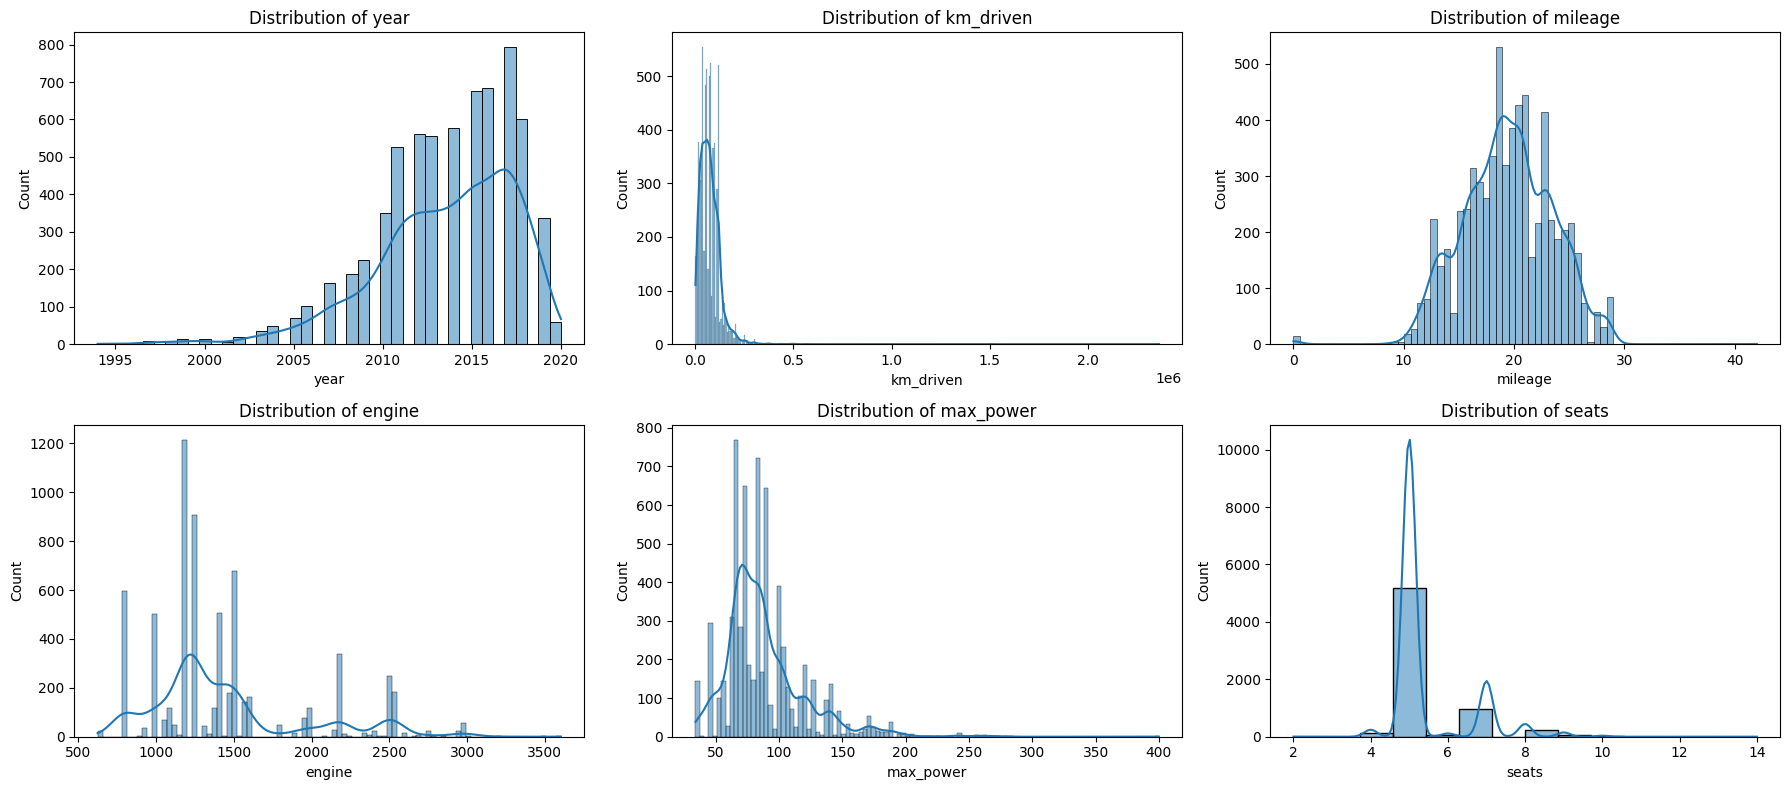

In [238]:

num_cols = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    
plt.tight_layout()
plt.show()


In [239]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6626 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           6626 non-null   int64  
 1   selling_price  6626 non-null   int64  
 2   km_driven      6626 non-null   int64  
 3   fuel           6626 non-null   int64  
 4   seller_type    6626 non-null   int64  
 5   transmission   6626 non-null   int64  
 6   owner          6626 non-null   int64  
 7   mileage        6626 non-null   float64
 8   engine         6626 non-null   float64
 9   max_power      6626 non-null   float64
 10  seats          6626 non-null   float64
 11  brand          6626 non-null   object 
dtypes: float64(4), int64(7), object(1)
memory usage: 673.0+ KB


In [240]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand
0,2014,450000,145500,1,1,1,1,23.40,1248.0,74.00,5.0,Maruti
1,2014,370000,120000,1,1,1,2,21.14,1498.0,103.52,5.0,Skoda
2,2006,158000,140000,0,1,1,3,17.70,1497.0,78.00,5.0,Honda
3,2010,225000,127000,1,1,1,1,23.00,1396.0,90.00,5.0,Hyundai
4,2007,130000,120000,0,1,1,1,16.10,1298.0,88.20,5.0,Maruti


### **One Hot Encoding**

In [241]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder

In [242]:
df =df.rename(columns={'name':'brand'})
df['brand']=df['brand'].str.split().str[0]

In [243]:
oneEncoder = OneHotEncoder(sparse_output=False, dtype=int)

for column in ['brand']:
    encoded = oneEncoder.fit_transform(df[[column]])
    df[oneEncoder.get_feature_names_out([column])] = encoded
    df.drop(column, axis = 1, inplace=True)

In [244]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,2014,450000,145500,1,1,1,1,23.40,1248.0,74.00,...,0,0,0,0,0,0,0,0,0,0
1,2014,370000,120000,1,1,1,2,21.14,1498.0,103.52,...,0,0,0,0,0,1,0,0,0,0
2,2006,158000,140000,0,1,1,3,17.70,1497.0,78.00,...,0,0,0,0,0,0,0,0,0,0
3,2010,225000,127000,1,1,1,1,23.00,1396.0,90.00,...,0,0,0,0,0,0,0,0,0,0
4,2007,130000,120000,0,1,1,1,16.10,1298.0,88.20,...,0,0,0,0,0,0,0,0,0,0


#### *Train and Test Split*

In [245]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [246]:
df['selling_price'].describe()

count    6.626000e+03
mean     5.267331e+05
std      5.116099e+05
min      2.999900e+04
25%      2.500000e+05
50%      4.220000e+05
75%      6.500000e+05
max      1.000000e+07
Name: selling_price, dtype: float64

In [247]:
np.log(df['selling_price'])

0       13.017003
1       12.821258
2       11.970350
3       12.323856
4       11.775290
          ...    
8121    12.468437
8122    13.071070
8123    12.676076
8124    11.813030
8125    12.853176
Name: selling_price, Length: 6626, dtype: float64

In [248]:

X = df.drop(columns='selling_price')
y = np.log(df['selling_price'])

print("BEFORE SPLIT:")
print(type(X))
print(type(y))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nAFTER SPLIT:")
print(type(X_train))
print(type(X_test))
print(type(y_train))
print(type(y_test))

BEFORE SPLIT:
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>

AFTER SPLIT:
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


### Scaling

In [249]:
X_train.head()

,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
3890,1995,70000,0,1,1,1,16.10,796.0,37.0,4.0,...,0,0,0,0,0,0,0,0,0,0
6291,2017,76000,1,0,1,1,25.47,1248.0,88.5,7.0,...,0,0,0,0,0,0,0,0,0,0
4492,2015,190000,1,1,1,1,12.99,2494.0,100.6,7.0,...,0,0,0,0,0,0,0,1,0,0
6794,2012,120000,1,1,1,1,23.03,1396.0,69.0,5.0,...,0,0,0,0,0,0,1,0,0,0
2786,2015,120000,1,1,1,2,19.10,1405.0,70.0,5.0,...,0,0,0,0,0,0,1,0,0,0


Scaling X_train and X_test

In [250]:
scaler = StandardScaler()

# Deciding on which cols to scale
scal_col = ['year', 'km_driven', 'mileage', 'engine', 'max_power']

print(X_train[scal_col].head())
for col in scal_col:
    print(X_train[col].describe())
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# print(X_train)
# print(X_test)
# print(X_train_scaled)
# print(X_test_scaled)

      year  km_driven  mileage  engine  max_power
3890  1995      70000    16.10   796.0       37.0
6291  2017      76000    25.47  1248.0       88.5
4492  2015     190000    12.99  2494.0      100.6
6794  2012     120000    23.03  1396.0       69.0
2786  2015     120000    19.10  1405.0       70.0
count    5300.000000
mean     2013.594528
std         3.910193
min      1994.000000
25%      2011.000000
50%      2014.000000
75%      2017.000000
max      2020.000000
Name: year, dtype: float64
count    5.300000e+03
mean     7.338788e+04
std      6.033798e+04
min      1.000000e+03
25%      3.700000e+04
50%      6.900000e+04
75%      1.000000e+05
max      2.360457e+06
Name: km_driven, dtype: float64
count    5300.000000
mean       19.449770
std         3.983584
min         0.000000
25%        16.800000
50%        19.400000
75%        22.500000
max        42.000000
Name: mileage, dtype: float64
count    5300.000000
mean     1437.537547
std       495.202420
min       624.000000
25%      1197.0

In [251]:
X_train[['year', 'km_driven']].head()

,year,km_driven
3890,1995,70000
6291,2017,76000
4492,2015,190000
6794,2012,120000
2786,2015,120000


In [252]:
X_train[['year', 'km_driven']].describe()

,year,km_driven
count,5300.000000,5.300000e+03
mean,2013.594528,7.338788e+04
std,3.910193,6.033798e+04
min,1994.000000,1.000000e+03
25%,2011.000000,3.700000e+04
50%,2014.000000,6.900000e+04
75%,2017.000000,1.000000e+05
max,2020.000000,2.360457e+06


In [253]:

print(X_train.head())
print(X_test.head())

X_train[scal_col] = scaler.fit_transform(X_train[scal_col])
X_test[scal_col] = scaler.fit_transform(X_test[scal_col])

print(X_train.head())
print(X_test.head())


      year  km_driven  fuel  seller_type  transmission  owner  mileage  \
3890  1995      70000     0            1             1      1    16.10   
6291  2017      76000     1            0             1      1    25.47   
4492  2015     190000     1            1             1      1    12.99   
6794  2012     120000     1            1             1      1    23.03   
2786  2015     120000     1            1             1      2    19.10   

      engine  max_power  seats  ...  brand_Mercedes-Benz  brand_Mitsubishi  \
3890   796.0       37.0    4.0  ...                    0                 0   
6291  1248.0       88.5    7.0  ...                    0                 0   
4492  2494.0      100.6    7.0  ...                    0                 0   
6794  1396.0       69.0    5.0  ...                    0                 0   
2786  1405.0       70.0    5.0  ...                    0                 0   

      brand_Nissan  brand_Opel  brand_Renault  brand_Skoda  brand_Tata  \
3890        

In [256]:
print(X_test.head())


          year  km_driven  fuel  seller_type  transmission  owner   mileage  \
5494 -0.693918   0.123808     0            1             1      2  0.416552   
5373  0.344024  -0.067244     1            1             1      1 -0.966428   
4693  0.603509   0.314860     1            1             0      2 -0.216707   
5722 -1.731860   0.696964     1            1             1      1 -2.155305   
5425 -0.953403   0.467701     1            1             1      1 -0.384121   

        engine  max_power  seats  ...  brand_Mercedes-Benz  brand_Mitsubishi  \
5494 -1.245303  -1.037726    5.0  ...                    0                 0   
5373  1.526861   0.991154    7.0  ...                    0                 0   
4693  0.133671   0.364957    7.0  ...                    0                 0   
5722  1.526861   0.991154    7.0  ...                    0                 0   
5425 -0.363897  -0.417790    5.0  ...                    0                 0   

      brand_Nissan  brand_Opel  brand_Renaul

<Axes: >

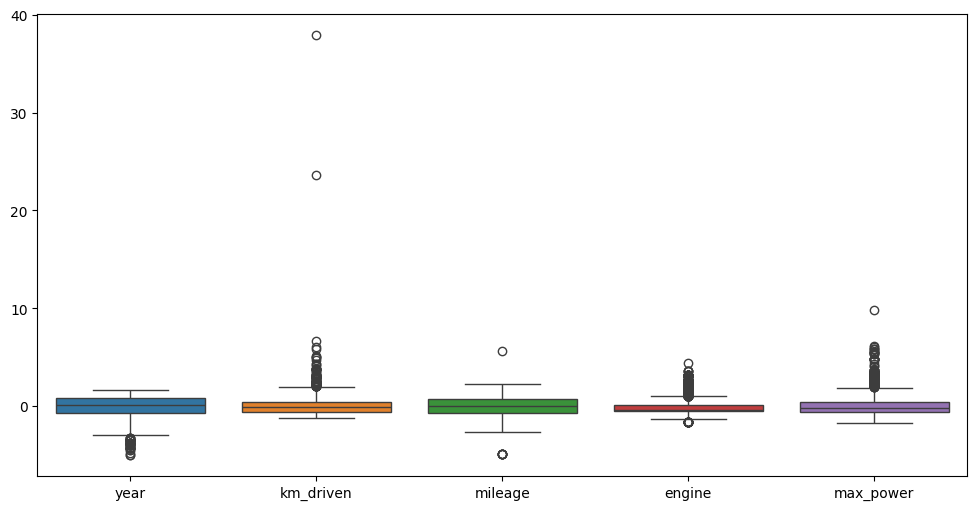

In [257]:
plt.figure(figsize=(12,6))


sns.boxplot(data=X_train[scal_col])


Data Visualization and Outlier Checks

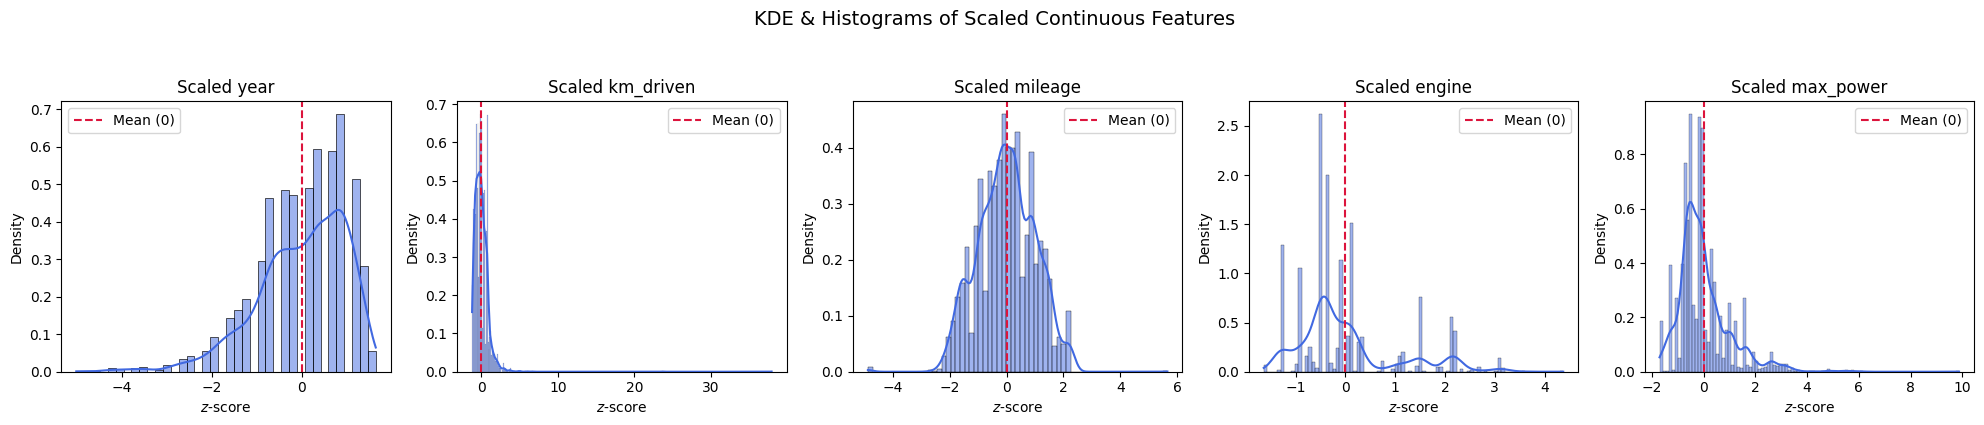

In [265]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(scal_col):
    sns.histplot(X_train[col], kde=True, ax=axes[i], color='royalblue', stat="density")
    axes[i].axvline(0, color='crimson', linestyle='--', label='Mean (0)')
    axes[i].set_title(f"Scaled {col}", fontsize=12)
    axes[i].set_xlabel("$z$-score")
    axes[i].set_ylabel("Density")
    axes[i].legend()
plt.suptitle("KDE & Histograms of Scaled Continuous Features", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

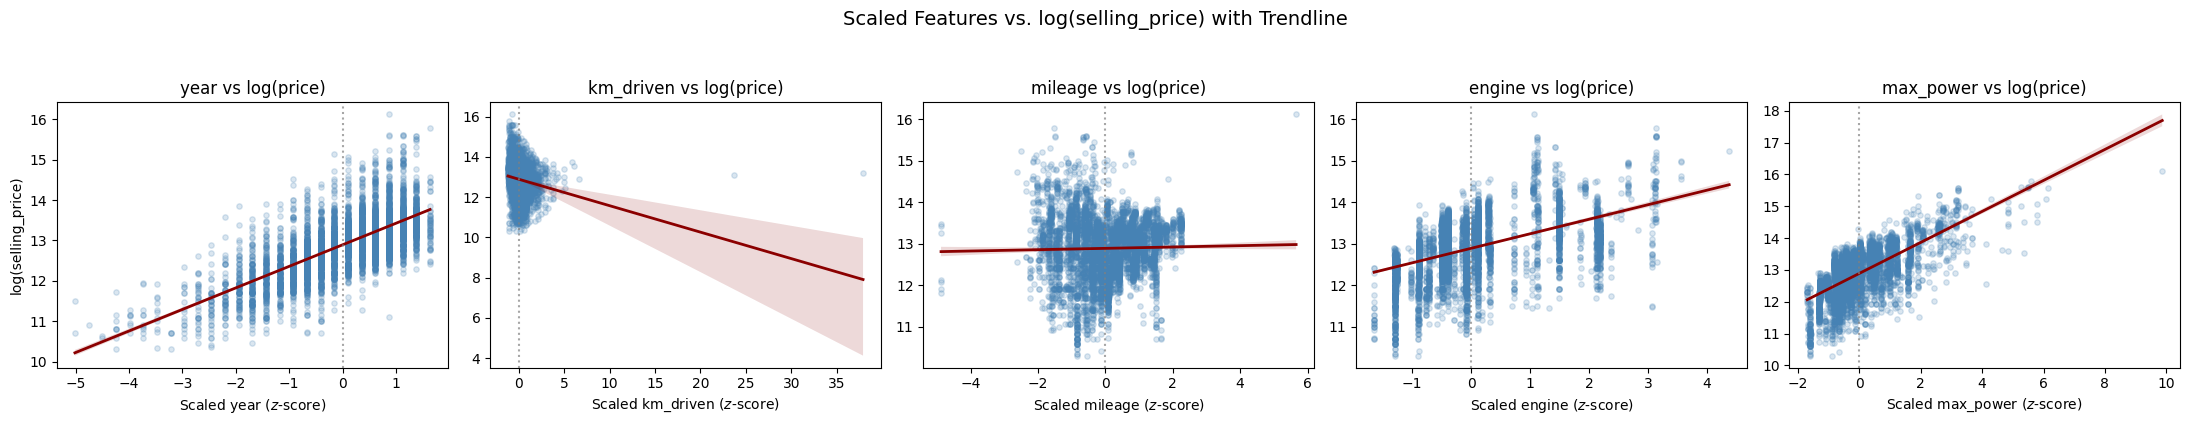

In [267]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for i, col in enumerate(scal_col):
    sns.regplot(
        x=X_train[col], 
        y=y_train, 
        ax=axes[i], 
        scatter_kws={'alpha': 0.2, 'color': 'steelblue', 's': 15}, 
        line_kws={'color': 'darkred', 'linewidth': 2}
    )
    axes[i].axvline(0, color='gray', linestyle=':', alpha=0.7)
    axes[i].set_title(f"{col} vs log(price)", fontsize=12)
    axes[i].set_xlabel(f"Scaled {col} ($z$-score)")
    axes[i].set_ylabel("log(selling_price)" if i == 0 else "")

plt.suptitle("Scaled Features vs. log(selling_price) with Trendline", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()


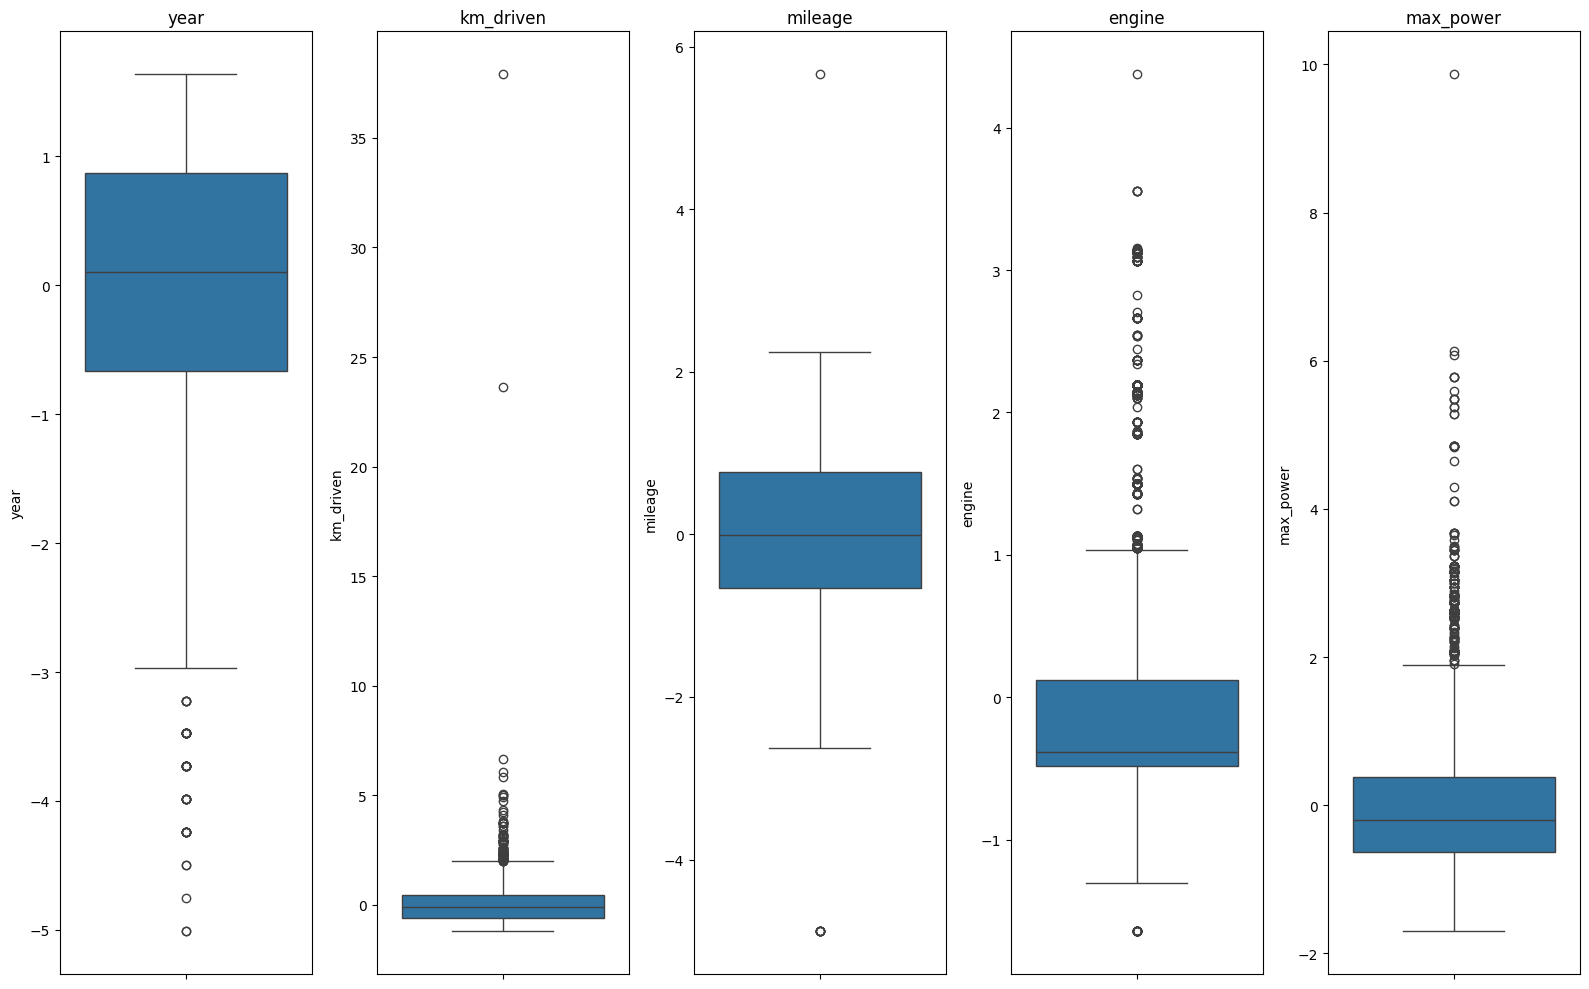

In [271]:
fig, axes = plt.subplots(1, len(scal_col), figsize=(16,10))

for i, col in enumerate(scal_col):
    sns.boxplot(data=X_train, y=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


In [273]:
# Count outliers per column using the standard IQR method

def outlier_count(col, data=X_train):
    q75, q25 = np.percentile(data[col], [75, 25])
    iqr = q75 - q25
    min_val = q25 - (iqr * 1.5)
    max_val = q75 + (iqr * 1.5)
    count = len(np.where((data[col] > max_val) | (data[col] < min_val))[0])
    percent = round(count / len(data[col]) * 100, 2)
    if count > 0:
        print("\n" + 15*'-' + col + 15*'-' + "\n")
        print('Number of outliers: {}'.format(count))
        print('Percent of data that is outlier: {}%'.format(percent))

for col in scal_col:
    outlier_count(col)



---------------year---------------

Number of outliers: 45
Percent of data that is outlier: 0.85%

---------------km_driven---------------

Number of outliers: 116
Percent of data that is outlier: 2.19%

---------------mileage---------------

Number of outliers: 8
Percent of data that is outlier: 0.15%

---------------engine---------------

Number of outliers: 979
Percent of data that is outlier: 18.47%

---------------max_power---------------

Number of outliers: 243
Percent of data that is outlier: 4.58%
